# College Algebra: Feynman's Direct/Inverse Operations, Typeset and Verified

Following [Feynman I, Ch. 22 ("Algebra")](https://www.feynmanlectures.caltech.edu/I_22.html),
this notebook typesets and VERIFIES the table of direct operations
(addition, multiplication, raising to a power) and their four inverses
(subtraction, division, root, logarithm) -- checked symbolically where a
rule holds identically, numerically where it only holds for positive
reals (Feynman's own caveat about continuity and ordering). It then
follows the historical log-table trick (multiplication via lookup +
addition, the pre-calculator method) into its direct computer-engineering
descendant: ROM lookup-table (LUT) addressing, where "how many bits index
a table of depth N" is literally the logarithm operation with base 2.
Engine: `dgs/elementary_algebra.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from dgs import elementary_algebra as ea

sp.init_printing(use_latex='mathjax')
print('Setup complete.')


Setup complete.


## 1. Eq. 22.1: The Direct Operations

Feynman's table has three "direct" operations, each with rules that hold
for the FIRST two (addition, multiplication) as blanket identities --
commutativity, associativity, distributivity:
$$a+b=b+a,\quad a+(b+c)=(a+b)+c,\quad ab=ba,\quad a(b+c)=ab+ac,\quad (ab)c=a(bc),$$
$$a+0=a,\quad a\cdot1=a,\quad a^1=a.$$

The THIRD direct operation, raising to a power, obeys a different-looking
set of rules that Feynman flags as holding only "under suitable
restrictions concerning continuity and ordering" -- i.e. NOT blanket
identities for all real $a,b,c$:
$$(ab)^c=a^c b^c,\qquad a^b a^c=a^{b+c},\qquad (a^b)^c=a^{bc}.$$

Checked two different ways below, matching which claim each actually is.


In [2]:
results_identities = ea.verify_direct_operation_rules()
for name, ok in results_identities.items():
    print(f'  {name}: {ok}')
print('\nall hold as blanket SYMBOLIC identities (sp.simplify(lhs-rhs)==0):',
      all(results_identities.values()))


  (a) a+b=b+a: True
  (b) a+(b+c)=(a+b)+c: True
  (c) ab=ba: True
  (d) a(b+c)=ab+ac: True
  (e) (ab)c=a(bc): True
  (i) a+0=a: True
  (j) a*1=a: True
  (k) a^1=a: True

all hold as blanket SYMBOLIC identities (sp.simplify(lhs-rhs)==0): True


In [3]:
results_power_laws = ea.verify_power_law_rules(a_val=2.0, b_val=3.0, c_val=5.0)
for name, ok in results_power_laws.items():
    print(f'  {name}: {ok}')
print('\nchecked NUMERICALLY at a=2,b=3,c=5 (positive reals) -- these do NOT')
print('simplify to 0 symbolically for arbitrary a,b,c, exactly Feynman\'s caveat')


  (f) (ab)^c=a^c*b^c: True
  (g) a^b*a^c=a^(b+c): True
  (h) (a^b)^c=a^(b*c): True

checked NUMERICALLY at a=2,b=3,c=5 (positive reals) -- these do NOT
simplify to 0 symbolically for arbitrary a,b,c, exactly Feynman's caveat


## 2. Eq. 22.2: The Four Inverse Operations

Each direct operation has an inverse that asks "what's missing?":
$$a+b=c\Rightarrow b=c-a,\qquad ab=c\Rightarrow b=c/a,$$
$$b^a=c\Rightarrow b=c^{1/a}\ \text{(root)},\qquad a^b=c\Rightarrow b=\log_a c\ \text{(logarithm)}.$$

Root and logarithm are BOTH "inverses of raising to a power," but they
invert DIFFERENT positions -- root solves for the base, logarithm solves
for the exponent. $b^2=8$ and $2^b=8$ are genuinely different equations
with genuinely different answers, verified (not just asserted) below.


In [4]:
a_val, c_val = 3, 12
print(f"(a') a+b={c_val} -> b = {ea.solve_for_missing_addend(a_val, c_val)}")
print(f"(b') {a_val}*b={c_val} -> b = {ea.solve_for_missing_factor(a_val, c_val)}")
print(f"(c') b^{a_val}={c_val} -> b = {float(ea.solve_for_root(a_val, c_val)):.6f}  (cube root of {c_val})")
print(f"(d') {a_val}^b={c_val} -> b = {float(ea.solve_for_logarithm(a_val, c_val)):.6f}  (log base {a_val} of {c_val})")


(a') a+b=12 -> b = 9
(b') 3*b=12 -> b = 4
(c') b^3=12 -> b = 2.289428  (cube root of 12)
(d') 3^b=12 -> b = 2.261860  (log base 3 of 12)


In [5]:
distinct_check = ea.verify_root_and_log_are_distinct_inverses(a_val=2.0, c_val=8.0)
print(f"root: b^2=8 -> b = {distinct_check['root (b^2=8)']:.6f}")
print(f"log:  2^b=8 -> b = {distinct_check['log (2^b=8)']:.6f}")
print(f"genuinely distinct operations: {distinct_check['distinct']}")


root: b^2=8 -> b = 2.828427
log:  2^b=8 -> b = 3.000000
genuinely distinct operations: True


## 3. The Historical Log-Table Trick: Multiplication via Addition

Before electronic calculators, multiplying two numbers by hand was done
via a table of logarithms (or a slide rule, its analog-computer
descendant): look up $\log_{10}x_1$ and $\log_{10}x_2$, ADD them (turning
multiplication into addition, an easier operation), then invert:
$$x_1 x_2 = 10^{\log_{10}x_1+\log_{10}x_2}.$$
This is Eq. 22.2's logarithm identity put to direct computational use --
verified below against ordinary floating-point multiplication.


In [6]:
xs, logs = ea.build_log_lookup_table(x_min=1.0, x_max=10.0, n_entries=100_000)
x1, x2 = 2.5, 3.5
lut_result = ea.multiply_via_log_table(x1, x2, xs, logs)
direct_result = x1 * x2
print(f'{x1} x {x2} via log-table lookup + addition = {lut_result:.6f}')
print(f'{x1} x {x2} via direct multiplication         = {direct_result:.6f}')
print(f'relative error: {abs(lut_result-direct_result)/direct_result:.2e}')


2.5 x 3.5 via log-table lookup + addition = 8.750000
2.5 x 3.5 via direct multiplication         = 8.750000
relative error: 2.45e-10


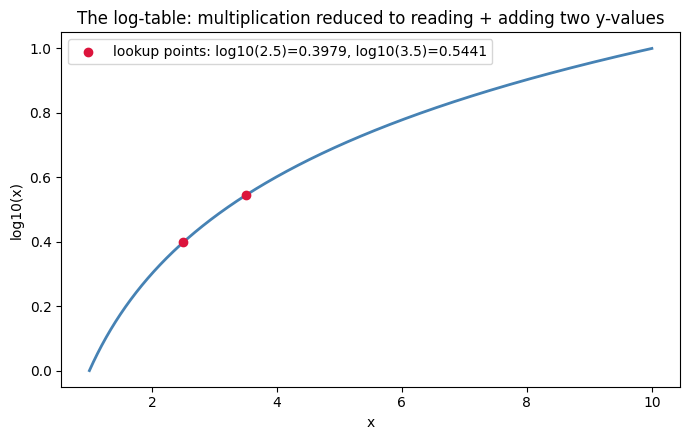

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(xs, logs, color='steelblue', lw=2)
ax.scatter([x1, x2], [np.log10(x1), np.log10(x2)], color='crimson', zorder=5,
           label=f'lookup points: log10({x1})={np.log10(x1):.4f}, log10({x2})={np.log10(x2):.4f}')
ax.set_xlabel('x'); ax.set_ylabel('log10(x)')
ax.set_title('The log-table: multiplication reduced to reading + adding two y-values')
ax.legend()
plt.tight_layout()
plt.savefig('elementary_algebra_log_table.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Table Resolution vs. Accuracy

A physical table of logarithms (or a modern LUT) only has finitely many
entries -- interpolation between them is where error enters. Sweep the
number of table entries and watch the relative error in the log-table
multiplication shrink.


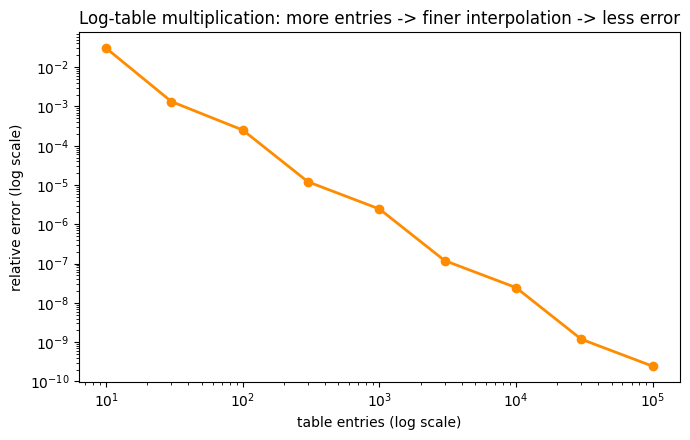

relative error at coarsest (10 entries):   3.03e-02
relative error at finest (100000 entries): 2.45e-10


In [8]:
entry_counts = np.array([10, 30, 100, 300, 1_000, 3_000, 10_000, 30_000, 100_000])
rel_errors = []
for n in entry_counts:
    result = ea.verify_log_table_multiplication(x1=2.5, x2=3.5, n_entries=int(n))
    rel_errors.append(result['relative_error'])
rel_errors = np.array(rel_errors)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(entry_counts, rel_errors, 'o-', color='darkorange', lw=2)
ax.set_xlabel('table entries (log scale)'); ax.set_ylabel('relative error (log scale)')
ax.set_title('Log-table multiplication: more entries -> finer interpolation -> less error')
plt.tight_layout()
plt.savefig('elementary_algebra_resolution_sweep.png', dpi=100, bbox_inches='tight')
plt.show()

print('relative error at coarsest (10 entries):  ', f'{rel_errors[0]:.2e}')
print('relative error at finest (100000 entries):', f'{rel_errors[-1]:.2e}')


## 5. The Computer-Engineering Descendant: ROM Lookup-Table Addressing

The exact same inverse-of-power operation, base 2 instead of base 10,
answers a hardware question: a lookup table with `table_depth` entries
needs
$$\text{address bits}=\lceil\log_2(\text{table\_depth})\rceil$$
binary address lines to select any entry -- Feynman's logarithm, doing
real work in a ROM's address decoder. Using a LUT instead of computing a
transcendental function exactly also has a finite-precision COST: the
worst-case quantization error is half the output step size,
$$\text{error}_{\max}=\frac{\text{function\_range}}{2\cdot 2^{\text{input\_bits}}}.$$


In [9]:
depths = [16, 256, 1024, 4096, 65536]
for depth in depths:
    bits = ea.lut_address_bits_for_depth(depth)
    print(f'  table depth {depth:6d} -> {bits:2d} address bits  '
          f'(log2({depth}) = {float(ea.solve_for_logarithm(2, depth)):.4f})')


  table depth     16 ->  4 address bits  (log2(16) = 4.0000)
  table depth    256 ->  8 address bits  (log2(256) = 8.0000)
  table depth   1024 -> 10 address bits  (log2(1024) = 10.0000)
  table depth   4096 -> 12 address bits  (log2(4096) = 12.0000)
  table depth  65536 -> 16 address bits  (log2(65536) = 16.0000)


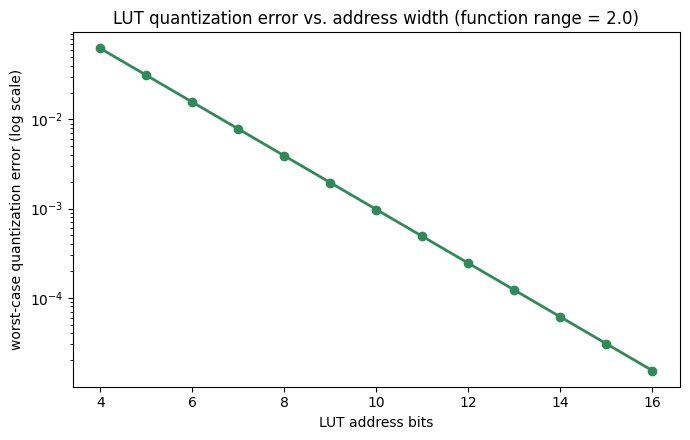

   8-bit LUT: worst-case error = 3.906250e-03  (256 entries)
  10-bit LUT: worst-case error = 9.765625e-04  (1024 entries)
  12-bit LUT: worst-case error = 2.441406e-04  (4096 entries)
  16-bit LUT: worst-case error = 1.525879e-05  (65536 entries)


In [10]:
input_bits_sweep = np.arange(4, 17)
function_range = 2.0   # e.g. a sine LUT spanning [-1, 1]
errors = [ea.lut_quantization_error_bound(int(b), function_range) for b in input_bits_sweep]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogy(input_bits_sweep, errors, 'o-', color='seagreen', lw=2)
ax.set_xlabel('LUT address bits'); ax.set_ylabel('worst-case quantization error (log scale)')
ax.set_title(f'LUT quantization error vs. address width (function range = {function_range})')
plt.tight_layout()
plt.savefig('elementary_algebra_lut_quantization.png', dpi=100, bbox_inches='tight')
plt.show()

for b in (8, 10, 12, 16):
    err = ea.lut_quantization_error_bound(b, function_range)
    print(f'  {b:2d}-bit LUT: worst-case error = {err:.6e}  ({2**b} entries)')


## 6. A Business Application: Doubling Time and the "Rule of 72"

An investment growing at rate $r$ per period satisfies $(1+r)^t=2$ at the
doubling time $t$ -- solving for $t$ is EXACTLY Feynman's logarithm inverse
operation again, base $1+r$ this time: $t=\log_{1+r}2$. The widely-used
"Rule of 72" business heuristic ($t\approx 72/(\text{rate in }\%)$) is an
approximation to this exact logarithm, checked below across a range of
rates rather than just quoted.


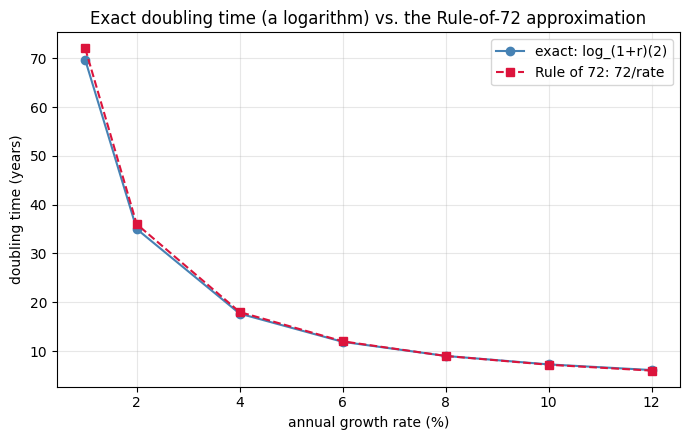

rate= 1%  exact=69.661 yr   rule-of-72=72.000 yr   error=3.36%
rate= 2%  exact=35.003 yr   rule-of-72=36.000 yr   error=2.85%
rate= 4%  exact=17.673 yr   rule-of-72=18.000 yr   error=1.85%
rate= 6%  exact=11.896 yr   rule-of-72=12.000 yr   error=0.88%
rate= 8%  exact=9.006 yr   rule-of-72=9.000 yr   error=0.07%
rate=10%  exact=7.273 yr   rule-of-72=7.200 yr   error=1.00%
rate=12%  exact=6.116 yr   rule-of-72=6.000 yr   error=1.90%


In [11]:
rates_pct = np.array([1, 2, 4, 6, 8, 10, 12])
exact_years = [float(ea.solve_for_logarithm(1 + r/100, 2)) for r in rates_pct]
rule_of_72 = 72 / rates_pct

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(rates_pct, exact_years, 'o-', color='steelblue', label='exact: log_(1+r)(2)')
ax.plot(rates_pct, rule_of_72, 's--', color='crimson', label='Rule of 72: 72/rate')
ax.set_xlabel('annual growth rate (%)'); ax.set_ylabel('doubling time (years)')
ax.set_title('Exact doubling time (a logarithm) vs. the Rule-of-72 approximation')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elementary_algebra_doubling_time.png', dpi=100, bbox_inches='tight')
plt.show()

for r, exact, approx in zip(rates_pct, exact_years, rule_of_72):
    print(f'rate={r:2d}%  exact={exact:.3f} yr   rule-of-72={approx:.3f} yr   '
          f'error={abs(exact-approx)/exact*100:.2f}%')


## 6b. The Taylor-Series Correction to the Rule of 72

Section 6's plot showed the Rule of 72's error *shrinking* toward 8% then
growing again -- not obviously why. The reason: $t=\log(2)/\log(1+r)$
diverges as $r\to0$ (it isn't a plain Taylor series in $r$), so its
small-$r$ behavior is an ASYMPTOTIC (Laurent) expansion, built here from
`dgs.taylor`'s Taylor-coefficient machinery applied to $\log(1+r)$ itself:
$$\log(1+r)=r-\tfrac12r^2+\tfrac13r^3-\cdots$$
Substituting into $t$ and re-expanding gives
$$t=\frac{\log2}{r}+\frac{\log2}{2}-\frac{\log2}{12}r+O(r^2).$$
The Rule of 72 keeps ONLY the leading $\log(2)/r\approx0.6931/r$ term
(tuned to 0.72 as an empirical compromise); the next term, $\log(2)/2
\approx0.347$, is an ADDITIVE correction -- this is the historical "Rule of
69.3, plus 0.35" refinement, derived here rather than quoted.


In [12]:
print('ln(1+r) Taylor coefficients (order 0..4):', ea.ln1pr_taylor_coefficients())
print('doubling-time asymptotic series:', ea.doubling_time_taylor_correction())


ln(1+r) Taylor coefficients (order 0..4): [0, 1, -1/2, 1/3, -1/4]
doubling-time asymptotic series: -r*log(2)/12 + log(2)/2 + log(2)/r


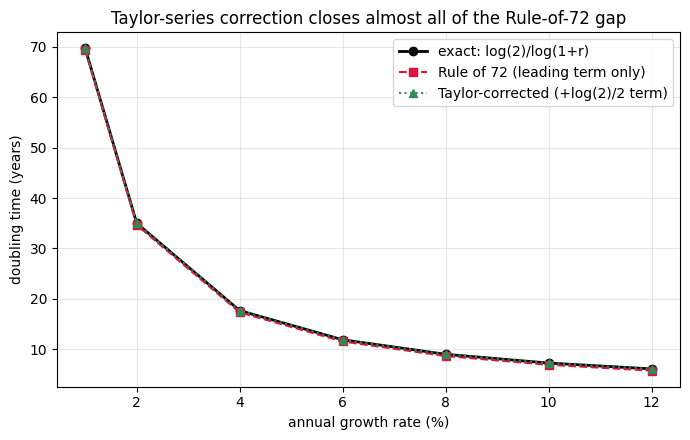

rate= 1%  exact=69.6607  first-order error=0.3460  corrected error=0.0000
rate= 6%  exact=11.8957  first-order error=0.3432  corrected error=0.0001
rate=12%  exact=6.1163  first-order error=0.3400  corrected error=0.0004


In [13]:
rates_check = np.array([1, 2, 4, 6, 8, 10, 12])
exact_c, first_order_c, corrected_c = [], [], []
for r in rates_check:
    result = ea.doubling_time_correction_check(int(r))
    exact_c.append(result['exact'])
    first_order_c.append(result['first_order'])
    corrected_c.append(result['corrected'])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(rates_check, exact_c, 'o-', color='black', lw=2, label='exact: log(2)/log(1+r)')
ax.plot(rates_check, first_order_c, 's--', color='crimson', label='Rule of 72 (leading term only)')
ax.plot(rates_check, corrected_c, '^:', color='seagreen', label='Taylor-corrected (+log(2)/2 term)')
ax.set_xlabel('annual growth rate (%)'); ax.set_ylabel('doubling time (years)')
ax.set_title('Taylor-series correction closes almost all of the Rule-of-72 gap')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elementary_algebra_taylor_correction.png', dpi=100, bbox_inches='tight')
plt.show()

for r in (1, 6, 12):
    result = ea.doubling_time_correction_check(r)
    print(f"rate={r:2d}%  exact={result['exact']:.4f}  "
          f"first-order error={result['first_order_error']:.4f}  "
          f"corrected error={result['corrected_error']:.4f}")


## 7. Engineering Interpretation

- Section 1's split matters: (a)-(e) are checked with `sp.simplify(...)==0`
  because they're identities for ALL $a,b,c$; (f)-(h) are checked with a
  numeric sample because they are NOT identities in general (they fail for
  negative bases with non-integer exponents) -- the verification METHOD
  itself encodes which mathematical claim is actually being made.
- Section 3's log-table trick is not a historical curiosity: it is the
  direct ancestor of the slide rule AND of modern fixed-point/LUT-based
  DSP multiply tricks -- turning an expensive operation (multiply) into a
  cheap one (add) via a monotonic transform is a recurring pattern.
- Section 4 shows the fundamental LUT trade directly: table depth (memory
  cost) vs. interpolation error -- the same trade every hardware sine/cosine
  or log LUT in a DSP or FPGA design has to make.
- Section 5 closes the loop to Feynman's OWN inverse-of-power operation:
  `lut_address_bits_for_depth` IS `solve_for_logarithm(2, depth)`, ceiling'd
  -- a 20th-century algebra rule directly answering a hardware design
  question ("how wide does this address bus need to be?").
- Section 6 shows the SAME logarithm inverse operation, applied with a
  different base ($1+r$ instead of $2$ or $10$), solving a business problem
  that looks nothing like a hardware address bus or a slide rule -- the
  point being that it's the identical algebraic operation each time, only
  the base and the question ("how many address bits" vs. "how many years")
  change.
- Section 6b confirms WHY the Rule of 72's error has the U-shape seen in
  section 6's plot: keeping only the leading $\log(2)/r$ term of an
  asymptotic (not plain Taylor) expansion is a first-order truncation, and
  the next term ($\log(2)/2\approx0.347$) is exactly the "corrected"
  curve's improvement -- a rule-of-thumb error, quantified and explained
  rather than just observed.


## 8. Research Discussion

- Could `lut_quantization_error_bound` be combined with section 4's
  interpolation-error sweep to find the OPTIMAL split between table depth
  (address bits) and interpolation order (nearest-neighbor vs. linear vs.
  higher-order) for a fixed total hardware budget (memory + multiply-add
  cost of interpolation)?
- The power-law rules (f)-(h) fail for negative bases with non-integer
  exponents -- could `verify_power_law_rules` be extended to sweep a grid
  of $(a,b,c)$ including negative and complex values, mapping out exactly
  WHERE the rules break (the "continuity and ordering" boundary Feynman
  mentions but doesn't detail)?
- Modern floating-point hardware still uses table-lookup-plus-correction
  (e.g. table-driven log/exp approximations, bipartite/multipartite table
  methods) for transcendental functions -- would tracing this notebook's
  log-table trick forward to an actual FPU's reciprocal/log unit design
  make a compelling "algebra rule you already know, in silicon" follow-up?
- Section 6b's correction is itself truncated at $O(r)$ -- extending
  `doubling_time_taylor_correction`'s `order` argument and plotting error
  vs. truncation order at a few fixed rates would show the expansion's own
  convergence behavior (and how many terms it actually takes to beat
  floating-point-visible agreement with the exact log formula).


## 9. Possible Experiments

1. Build a LUT-based sine approximator (`dgs/`-style module): compare its
   error and memory cost against `lut_quantization_error_bound`'s
   prediction for several address-bit widths.
2. Extend `verify_power_law_rules` to a grid sweep over negative and
   fractional $a,b,c$ and PLOT where each of (f)-(h) starts failing, giving
   a concrete picture of "suitable restrictions concerning continuity and
   ordering."
3. Implement `multiply_via_log_table` using FIXED-POINT arithmetic (not
   floats) to see how quantization in the table VALUES (not just table
   DEPTH) contributes additional error on top of section 4's sweep.
4. Pull a real savings-account APY or loan rate and compare the EXACT
   logarithm-based doubling/payoff time (section 6) against the mental-math
   Rule-of-72 shortcut for that specific rate.


## 10. Future Improvements

- `build_log_lookup_table` uses linear interpolation (`np.interp`)
  implicitly; comparing against a quadratic or cubic-spline interpolated
  table at fixed depth would show how much of section 4's error is
  interpolation-order-limited vs. depth-limited.
- `lut_address_bits_for_depth` assumes depth is checked directly; a
  natural next module would connect this to `dgs/logic_timing.py`'s
  `Circuit`/critical-path machinery to size an actual ROM address decoder
  and estimate its propagation delay as a function of address width.
